# PPE with Yolov26
src:
- [Ultralytics PPE Datasets](https://docs.ultralytics.com/datasets/detect/construction-ppe/#dataset-structure)
- [Dataset Zipfile](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/construction-ppe.yaml)
- [how to train ppe dataset](https://github.com/ultralytics/notebooks/blob/main/notebooks/how-to-train-ultralytics-yolo-on-construction-ppe-detection-dataset.ipynb) by Ultralytics

In [19]:
import os
from pathlib import Path
import requests
import zipfile
import yaml
import json
import shutil
# DS DV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Datasets CV
import ultralytics
from ultralytics import YOLO
from ultralytics import settings
import cv2
# DL
import torch
# Utils
import random
from collections import Counter
import gc
from tqdm import tqdm
ultralytics.checks()

Ultralytics 8.4.6  Python-3.11.3 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
Setup complete  (20 CPUs, 127.9 GB RAM, 639.8/3726.0 GB disk)


In [ ]:
# define path
CURRENT_DIR = Path.cwd()
DATA_DIR = CURRENT_DIR / "data"
LOGS_DIR = CURRENT_DIR / "logs"
OUTPUTS_DIR = CURRENT_DIR / "outputs"
# create dirs if not exists
DATA_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

### 1. Download and extract datasets
- [Ultralytics PPE Dataset]("https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip")

In [8]:
# download the ppe dataset
ppe_dataset_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
ppe_dataset_dir = DATA_DIR / "construction-ppe"
ppe_dataset_dir.mkdir(parents=True, exist_ok=True)
ppe_zipfile_path = ppe_dataset_dir / "construction-ppe.zip"

In [10]:
# Uncomment the code below to download the dataset if not exists
print("Downloading PPE Contruction dataset from Ultralytics...")
response = requests.get(ppe_dataset_url)

with open(ppe_zipfile_path, "wb") as f:
    f.write(response.content)

In [11]:
# extract the zip file
# uncomment the cell if the you need to extract the zip
print("extracting dataset...")
with zipfile.ZipFile(ppe_zipfile_path, "r") as zip_ref:
    zip_ref.extractall(ppe_dataset_dir)
print("Done!")

extracting dataset...
Done!


### 2. Explore the Data (EDA)

In [17]:
# read yaml config file
yaml_path =  DATA_DIR / "construction-ppe" / "sscv_data.yaml"
try:
    with open(yaml_path, "r", encoding="utf-8") as f:
        dataset_config = yaml.safe_load(f)

except UnicodeDecodeError as e:
    print(f"Unicode Error: {e}")
print("="*70)
print("CONSTRUCTION PPE DATASET")
print("="*70)
print(f"\nDataset config:")
print(f"  nbr of Classes: {len(dataset_config['names'])} == nc: {dataset_config['nc']}")
for class_id, class_name in dataset_config["names"].items():
    print(f"{'':8}{class_id}: {class_name}")

CONSTRUCTION PPE DATASET

Dataset config:
  nbr of Classes: 5 == nc: 5
        0: helmet
        1: gloves
        2: vest
        3: boots
        4: goggles


- train model params: https://docs.ultralytics.com/modes/train/#train-settings

In [23]:
#  ensure a copy of the dataset
# original folders
IMAGES_DIR = ppe_dataset_dir / "images"
LABELS_DIR = ppe_dataset_dir / "labels"
# cleaned v1 dirs
V1_DIR = ppe_dataset_dir / "v1"
V1_IMAGES = V1_DIR / "images"
V1_LABELS = V1_DIR / "labels"
# selected ppe classes
PPE_V1_CLASSES = {0, 1, 2, 3, 4}
SPLITS = ["train", "val", "test"]

In [22]:
# create dir stucture
for split in SPLITS:
    (V1_IMAGES / split).mkdir(parents=True, exist_ok=True)
    (V1_LABELS / split).mkdir(parents=True, exist_ok=True)
print(f"V1 dir created!")

V1 dir created!


In [24]:
# clean label and copy matching images
def clean_split(split):
    src_img_dir = IMAGES_DIR / split
    src_lbl_dir = LABELS_DIR / split
    dst_img_dir = V1_IMAGES / split
    dst_lbl_dir = V1_LABELS / split

    kept_images = 0
    for label_path in src_lbl_dir.glob("*.txt"):
        lines = label_path.read_text().splitlines()
        # filter and keep only desired classes
        filtered = [line for line in lines if int(line.split()[0]) in PPE_V1_CLASSES]
        # skip empty labels
        if not filtered:
            continue
        # write cleaned label
        dst_label_path = dst_lbl_dir / label_path.name
        dst_label_path.write_text("\n".join(filtered))
        # copy corresponding image
        image_name = label_path.stem
        for ext in [".jpg", ".png", ".jpeg"]:
            img_path = src_img_dir / f"{image_name}{ext}"
            if img_path.exists():
                shutil.copy(img_path, dst_img_dir / img_path.name)
                kept_images += 1
                break
    print(f"{split}: kept {kept_images} images")

In [25]:
for split in SPLITS:
    clean_split(split)

train: kept 946 images
val: kept 121 images
test: kept 123 images


In [26]:
# check images
for split in SPLITS:
    n_images = len(list((V1_IMAGES / split).glob("*")))
    n_labels = len(list((V1_LABELS / split).glob("*.txt")))
    print(f"{split}: {n_images} images | {n_labels} labels")

train: 946 images | 956 labels
val: 121 images | 121 labels
test: 123 images | 123 labels


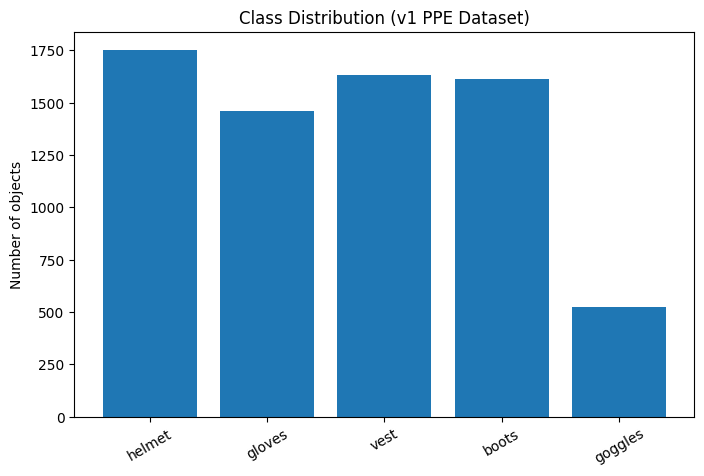

In [27]:
# visualize class distribution
class_counter = Counter()

for split in SPLITS:
    for label_file in (V1_LABELS / split).glob("*.txt"):
        for line in label_file.read_text().splitlines():
            cls_id = int(line.split()[0])
            class_counter[cls_id] += 1

class_names = {
    0: "helmet",
    1: "gloves",
    2: "vest",
    3: "boots",
    4: "goggles"
}

labels = [class_names[k] for k in sorted(class_counter)]
values = [class_counter[k] for k in sorted(class_counter)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Class Distribution (v1 PPE Dataset)")
plt.ylabel("Number of objects")
plt.xticks(rotation=30)
plt.show()

In [28]:
def show_random_image(split="train"):
    images = list((V1_IMAGES / split).glob("*"))
    img_path = random.choice(images)

    label_path = (V1_LABELS / split / img_path.stem).with_suffix(".txt")
    img = cv2.imread(str(img_path))
    h, w, _ = img.shape

    # https://docs.ultralytics.com/datasets/detect/
    for line in label_path.read_text().splitlines():
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            class_names[int(cls)],
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

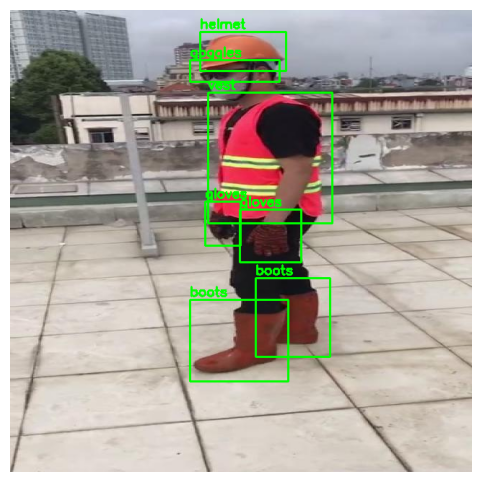

In [29]:
show_random_image("train")